# Product Price Prediction on historical data


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [85]:
df = pd.read_csv("../data/product_retail_prices.csv")

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Year              118482 non-null  int64  
 1   Month             118482 non-null  object 
 2   GEO               118482 non-null  object 
 3   Product Category  118482 non-null  object 
 4   Products          118482 non-null  object 
 5   VALUE             118482 non-null  float64
 6   Taxable           118482 non-null  object 
 7   Total tax rate    118482 non-null  float64
 8   Value after tax   118482 non-null  float64
 9   Essential         118482 non-null  object 
 10  COORDINATE        118482 non-null  float64
 11  UOM               118482 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 10.8+ MB


In [87]:
# Select features
X = df[[
    "Month", "Year", "GEO", "Product Category", "Products",
    "Taxable", "Value after tax", "Essential", "UOM"
]]
y = df["VALUE"]

In [88]:
# Identify categorical and numeric columns
categorical_cols = [
    "Month", "GEO", "Product Category", "Products",
    "Taxable", "Value after tax", "Essential", "UOM"
]
numeric_cols = ["Year"]

In [89]:
# Column transformer: OneHotEncode categorical, scale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", RobustScaler(), numeric_cols)
    ]
)

In [90]:
# Build pipeline with SGDRegressor
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(random_state=42))
])

In [91]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
# Hyperparameter tuning
param_grid = {
    "regressor__max_iter": [1000, 2000],
    "regressor__alpha": [0.0001, 0.001, 0.01],
    "regressor__learning_rate": ["adaptive", "invscaling"],
    "regressor__eta0": [0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    pipeline, param_grid,
    cv=3, n_jobs=-1, scoring="r2", verbose=1
)
grid.fit(X_train, y_train)

print("✅ Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
✅ Best Parameters: {'regressor__alpha': 0.0001, 'regressor__eta0': 0.1, 'regressor__learning_rate': 'adaptive', 'regressor__max_iter': 1000}


In [93]:
# Evaluate best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.62
Root Mean Squared Error (RMSE): 1.20
R² Score: 0.9448


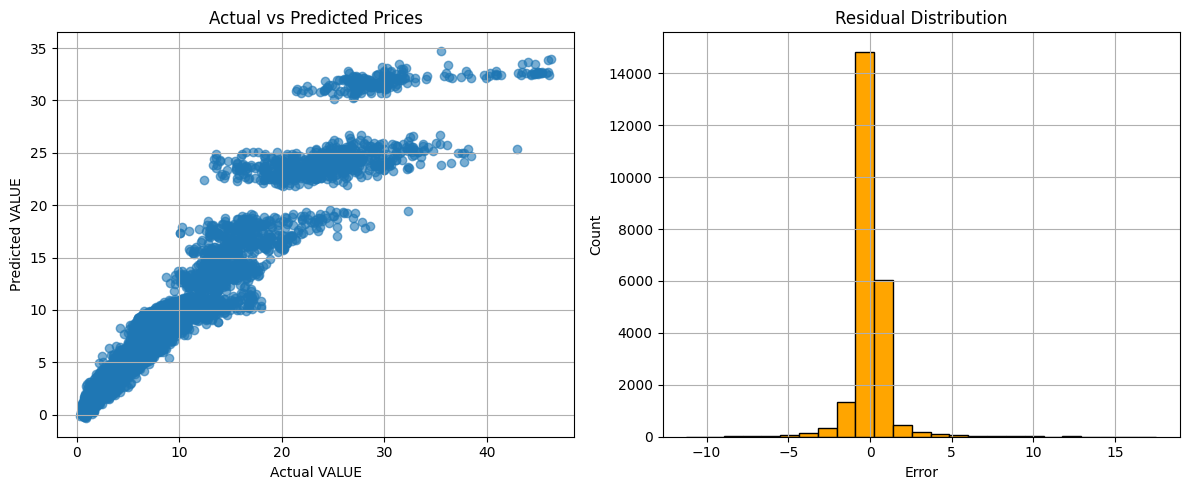

In [94]:
# Visualization
plt.figure(figsize=(12, 5))

# Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual VALUE")
plt.ylabel("Predicted VALUE")
plt.title("Actual vs Predicted Prices")
plt.grid(True)

# Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.hist(residuals, bins=25, color="orange", edgecolor="black")
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()